<div>
<img src="https://www.cosmos.esa.int/documents/3414525/0/Logo_Gaia_may_23_2022.png/cf6be61e-609e-27dc-3ad6-03ac5209bdc4?t=1653299950248" width="300" align="right"/>
</div>

# Tutorial:  Transform input & output units using Astropy+Astroquery

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />


---
Copyright (c) European Space Agency, 2025.

This file is subject to the terms and conditions defined in file **[LICENSE.txt](LICENSE.txt)**, which
is part of this source code package. No part of the package, including
this file, may be copied, modified, propagated, or distributed except according to
the terms contained in the file **[LICENSE.txt](LICENSE.txt)**.

---

**Release number:** 
v1.1 (2025-05-30)


**Applicable Gaia Data Releases:**
Gaia EDR3, Gaia DR3


**Summary:** 

This code shows how to use the [Astropy.units](https://docs.astropy.org/en/stable/units/index.html) Python module to transform the units associated to different fields in several Gaia DR3 catalogues. For more information, see also the [Astropy equivalencies](https://docs.astropy.org/en/stable/units/equivalencies.html) documentation.

**Useful URLs:**

* [Questions or suggestions](https://www.cosmos.esa.int/web/gaia/questions)
* [Tutorials, documentation, and more](https://www.cosmos.esa.int/web/gaia-users/archive)
* [Known issues in the Gaia data](https://www.cosmos.esa.int/web/gaia-users/known-issues)
* [Gaia data credits and acknowledgements](https://www.cosmos.esa.int/web/gaia-users/credits)

In [1]:
from astropy import units as u
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Important: Gaia archive will be intermittently unavailable due to scheduled maintenance (deployment of a new version) on Wednesday 4th from 11h to 12h


## Connect to the Gaia Archive


In [2]:
Gaia.login()

INFO: Login to gaia TAP server [astroquery.gaia.core]


User:  hcanovas
Password:  ········


INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]


##  Retrieve all sources contained in a spherical volume (roughly) centred on the Solar System barycentre, and estimate their distances in light years

The query below retrieves all Gaia (E)DR3 sources having distance estimates lower than 10 light years and RUWE <1.4. Then it converts distance units (parallax) to light years, and radial velocity units to m/s. Note the use of Python f-strings (https://docs.python.org/3/tutorial/inputoutput.html) to easily include variables into the ADQL query.

In [3]:
dist_lim    = 10.0 * u.lightyear                                # Spherical radius in Light Years
dist_lim_pc = dist_lim.to(u.parsec, equivalencies=u.parallax()) # Spherical radius in Parsec

query = f"SELECT source_id, ra, dec, parallax, distance_gspphot, teff_gspphot, azero_gspphot, phot_g_mean_mag, radial_velocity \
FROM gaiadr3.gaia_source \
WHERE distance_gspphot <= {dist_lim_pc.value}\
AND ruwe <1.4"

job     = Gaia.launch_job_async(query)
results = job.get_results()
print(f'Table size (rows): {len(results)}')

results['distance_lightyear'] = results['distance_gspphot'].to(u.lightyear)
results['radial_velocity_ms'] = results['radial_velocity'].to(u.meter/u.second)
results

INFO: Query finished. [astroquery.utils.tap.core]
Table size (rows): 4


source_id,ra,dec,parallax,distance_gspphot,teff_gspphot,azero_gspphot,phot_g_mean_mag,radial_velocity,distance_lightyear,radial_velocity_ms
,deg,deg,mas,pc,K,mag,mag,km / s,lyr,m / s
int64,float64,float64,float64,float32,float32,float32,float32,float32,float32,float32
5853498713190525696,217.39232147200883,-62.67607511676666,768.0665391873573,1.3011,2829.3542,0.0,8.984749,-21.942726,4.243621,-21942.727
4472832130942575872,269.44850252543836,4.739420051112412,546.975939730948,1.8275,3099.6335,1e-04,8.1939745,-110.46822,5.960508,-110468.23
762815470562110464,165.83095967577933,35.948653032660104,392.75294543876464,2.5453,3511.045,0.0,6.551172,-85.11064,8.301659,-85110.64
4075141768785646848,282.4587890175222,-23.83709744872712,336.0266016683708,2.9762,3117.376,0.0002,9.126414,-11.11644,9.707067,-11116.439


## Retrieve sources with estimated $\mathrm{H\alpha}$ equivalent widths above an arbitrary threshold in nm. Convert it to  $\unicode{x212B}$


In [4]:
query = f"SELECT source_id, classprob_dsc_allosmod_star, teff_gspphot, logg_gspphot, mh_gspphot, distance_gspphot, azero_gspphot, radius_gspphot, ew_espels_halpha,  spectraltype_esphs \
FROM gaiadr3.astrophysical_parameters \
WHERE ew_espels_halpha BETWEEN -10 AND -5 AND \
distance_gspphot <300 \
AND spectraltype_esphs != 'unknown' \
ORDER BY ew_espels_halpha"

job     = Gaia.launch_job_async(query)
results = job.get_results()
print(f'Table size (rows): {len(results)}')

results['ew_espels_halpha_AA'] = results['ew_espels_halpha'].to(u.Angstrom)
results

INFO: Query finished. [astroquery.utils.tap.core]
Table size (rows): 19


source_id,classprob_dsc_allosmod_star,teff_gspphot,logg_gspphot,mh_gspphot,distance_gspphot,azero_gspphot,radius_gspphot,ew_espels_halpha,spectraltype_esphs,ew_espels_halpha_AA
,,K,log(cm.s**-2),dex,pc,mag,solRad,nm,,Angstrom
int64,float32,float32,float32,float32,float32,float32,float32,float32,object,float32
6014696635395955200,1.0,5806.3936,4.3735,-4.084,152.1869,5.8891,0.9871,-7.905174,M,-79.051735
548687019867141248,1.0,3469.1199,4.8496,-0.1202,234.534,0.0096,0.4027,-7.546674,M,-75.466736
6237174395139447808,1.0,3220.2583,4.5578,0.4907,136.8067,0.655,0.6153,-7.336281,M,-73.36281
5977507918028936576,0.9999994,3126.9832,4.8348,0.4441,183.2773,0.9097,0.3931,-7.310384,M,-73.103836
121404161224865024,1.0,4574.8843,4.1231,-0.22,248.9513,8.7493,1.4332,-7.223885,M,-72.23885
4107841656992427520,1.0,5263.2603,4.7417,-3.3261,167.7344,6.7026,0.5372,-6.7767243,M,-67.76724
163184091252903936,1.0,5576.3228,4.2722,-3.8674,131.5889,3.3878,1.1495,-6.662208,K,-66.62208
6045861811448120320,1.0,3100.6733,4.378,0.4982,147.2943,2.3035,0.7069,-6.436306,M,-64.36306


## Retrieve masses from low-mass binary pairs, and convert them to Jupiter masses.

Note: Brown dwarfs upper limit ~ 0.075 $M_{\odot}$ (~ 75 $M_\mathrm{Jup}$)

In [5]:
query = f"SELECT * \
FROM gaiadr3.binary_masses \
WHERE m1 <0.125 \
ORDER BY m1"

job     = Gaia.launch_job_async(query)
results = job.get_results()
print(f'Table size (rows): {len(results)}')

results['m1_jup_mass'] = results['m1'].to(u.jupiterMass)
results['m2_jup_mass'] = results['m2'].to(u.jupiterMass)
results

INFO: Query finished. [astroquery.utils.tap.core]
Table size (rows): 5


source_id,m1,m1_lower,m1_upper,m2,m2_lower,m2_upper,fluxratio,fluxratio_lower,fluxratio_upper,combination_method,m1_ref,flag,m1_jup_mass,m2_jup_mass
,solMass,solMass,solMass,solMass,solMass,solMass,,,,,,,jupiterMass,jupiterMass
int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,object,object,object,float32,float32
4580216762992082048,0.118804775,0.07159802,0.16601153,--,0.04972383,0.07908957,--,0.13,--,Orbital+M1,IsocLum,,124.45579,nan
5557776367807067648,0.12185247,0.07464338,0.17008784,0.067699336,0.053124726,0.08328539,--,0.0,0.0,Orbital+M1,IsocLum,,127.64845,70.919495
845583819682861184,0.122110225,0.074233726,0.16946633,0.08028531,0.06197444,0.09972578,--,0.0,0.0,Orbital+M1,IsocLum,,127.918465,84.104126
4406489184157821952,0.122521155,0.07496838,0.1705908,0.07285931,0.05727609,0.089689784,--,0.0,0.0,Orbital+M1,IsocLum,,128.34894,76.324905
3230836376154368384,0.124612674,0.076774806,0.17298208,0.04927069,0.038072873,0.0609185,--,0.0,0.0,Orbital+M1,IsocLum,,130.53995,51.614277


## Select Cepheids with Fundamental pulsation mode below 15 hours.

In [6]:
pf_lim_hd = 15 * u.hour
pf_lim_dd = pf_lim_hd.to(u.day)

query = f'SELECT source_id, pf, pf_error, ap.teff_gspphot, ap.logg_gspphot, ap.mh_gspphot, ap.distance_gspphot, ap.azero_gspphot, ap.radius_gspphot, ap.ew_espels_halpha,  ap.spectraltype_esphs \
FROM gaiadr3.vari_cepheid \
JOIN gaiadr3.astrophysical_parameters AS ap USING (source_id) \
WHERE pf <{pf_lim_dd.value}'


job     = Gaia.launch_job_async(query)
results = job.get_results()
print(f'Table size (rows): {len(results)}')

results['pf_hour']        = results['pf'].to(u.hour)
results['pf_hour'].format = '5.3f'
results

INFO: Query finished. [astroquery.utils.tap.core]
Table size (rows): 9


source_id,pf,pf_error,teff_gspphot,logg_gspphot,mh_gspphot,distance_gspphot,azero_gspphot,radius_gspphot,ew_espels_halpha,spectraltype_esphs,pf_hour
,d,d,K,log(cm.s**-2),dex,pc,mag,solRad,nm,,h
int64,float64,float32,float32,float32,float32,float32,float32,float32,float32,object,float64
5188379665334866176,0.6219627800893595,8.736139e-06,6173.523,3.1676,-0.9927,2478.2385,0.1601,5.1871,0.19384572,unknown,14.927
4685852200899088512,0.5822570063616527,1.6833055e-06,5521.2,4.7306,-3.7822,3203.7131,0.0121,0.5741,--,,13.974
5861380317401194752,0.5866106007286351,1.3795823e-06,9060.484,4.1245,-0.7119,1867.7528,4.696,1.8368,0.03517555,F,14.079
5861754598036185344,0.6002593393511508,2.7811316e-06,--,--,--,--,--,--,0.2204732,G,14.406
5926569816398338304,0.5910341676058103,8.15525e-07,8406.448,4.065,-1.2239,1941.2487,3.4149,1.7847,0.16679318,B,14.185
4702941119846080128,0.5644549970314298,5.2175283e-06,6616.0835,4.5777,-2.4239,6389.3247,0.0061,0.7866,--,,13.547
5422477922959825792,0.5597106717764326,1.2912872e-06,8226.137,3.5066,-0.066,1930.5466,5.4515,4.6715,0.26228103,B,13.433
5864522588553955584,0.5990258658944467,1.9770755e-07,7514.7837,3.3402,-0.296,2169.1348,4.0485,5.2538,0.23103149,F,14.377


## Compute Flux density (in mJy) from XP sampled spectrum. 

The code below retrieves XP sample spectra for 10 arbitrary sources in Gaia DR3. This product can be downloaded via a dedicated DataLink server (for details, see the DataLink tutorials available [here](https://www.cosmos.esa.int/web/gaia-users/archive/datalink-products)). Note: the download of this product raises a warning in the Astropy.units module. This is a known issue and we are working on it.

### Retrieve a set of sources with XP Sampled spectra

In [7]:
query = f"SELECT TOP 10 * FROM gaiadr3.gaia_source \
WHERE has_xp_sampled = 'True'"

job     = Gaia.launch_job_async(query)
results = job.get_results()
results

INFO: Query finished. [astroquery.utils.tap.core]


solution_id,designation,source_id,random_index,ref_epoch,ra,ra_error,dec,dec_error,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,pmdec,pmdec_error,ra_dec_corr,ra_parallax_corr,ra_pmra_corr,ra_pmdec_corr,dec_parallax_corr,dec_pmra_corr,dec_pmdec_corr,parallax_pmra_corr,parallax_pmdec_corr,pmra_pmdec_corr,astrometric_n_obs_al,astrometric_n_obs_ac,astrometric_n_good_obs_al,astrometric_n_bad_obs_al,astrometric_gof_al,astrometric_chi2_al,astrometric_excess_noise,astrometric_excess_noise_sig,astrometric_params_solved,astrometric_primary_flag,nu_eff_used_in_astrometry,pseudocolour,pseudocolour_error,ra_pseudocolour_corr,dec_pseudocolour_corr,parallax_pseudocolour_corr,pmra_pseudocolour_corr,pmdec_pseudocolour_corr,astrometric_matched_transits,visibility_periods_used,astrometric_sigma5d_max,matched_transits,new_matched_transits,matched_transits_removed,ipd_gof_harmonic_amplitude,ipd_gof_harmonic_phase,ipd_frac_multi_peak,ipd_frac_odd_win,ruwe,scan_direction_strength_k1,scan_direction_strength_k2,scan_direction_strength_k3,scan_direction_strength_k4,scan_direction_mean_k1,scan_direction_mean_k2,scan_direction_mean_k3,scan_direction_mean_k4,duplicated_source,phot_g_n_obs,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_n_obs,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_n_obs,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,phot_bp_n_contaminated_transits,phot_bp_n_blended_transits,phot_rp_n_contaminated_transits,phot_rp_n_blended_transits,phot_proc_mode,bp_rp,bp_g,g_rp,radial_velocity,radial_velocity_error,rv_method_used,rv_nb_transits,rv_nb_deblended_transits,rv_visibility_periods_used,rv_expected_sig_to_noise,rv_renormalised_gof,rv_chisq_pvalue,rv_time_duration,rv_amplitude_robust,rv_template_teff,rv_template_logg,rv_template_fe_h,rv_atm_param_origin,vbroad,vbroad_error,vbroad_nb_transits,grvs_mag,grvs_mag_error,grvs_mag_nb_transits,rvs_spec_sig_to_noise,phot_variable_flag,l,b,ecl_lon,ecl_lat,in_qso_candidates,in_galaxy_candidates,non_single_star,has_xp_continuous,has_xp_sampled,has_rvs,has_epoch_photometry,has_epoch_rv,has_mcmc_gspphot,has_mcmc_msc,in_andromeda_survey,classprob_dsc_combmod_quasar,classprob_dsc_combmod_galaxy,classprob_dsc_combmod_star,teff_gspphot,teff_gspphot_lower,teff_gspphot_upper,logg_gspphot,logg_gspphot_lower,logg_gspphot_upper,mh_gspphot,mh_gspphot_lower,mh_gspphot_upper,distance_gspphot,distance_gspphot_lower,distance_gspphot_upper,azero_gspphot,azero_gspphot_lower,azero_gspphot_upper,ag_gspphot,ag_gspphot_lower,ag_gspphot_upper,ebpminrp_gspphot,ebpminrp_gspphot_lower,ebpminrp_gspphot_upper,libname_gspphot
,,,,yr,deg,mas,deg,mas,mas,mas,,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr,,,,,,,,,,,,,,,,,mas,,,,1 / um,1 / um,1 / um,,,,,,,,mas,,,,,deg,,,,,,,,deg,deg,deg,deg,,,electron / s,electron / s,,mag,,electron / s,electron / s,,mag,,electron / s,electron / s,,mag,,,,,,,mag,mag,mag,km / s,km / s,,,,,,,,d,km / s,K,log(cm.s**-2),dex,,km / s,km / s,,mag,mag,,,,deg,deg,deg,deg,,,,,,,,,,,,,,,K,K,K,log(cm.s**-2),log(cm.s**-2),log(cm.s**-2),dex,dex,dex,pc,pc,pc,mag,mag,mag,mag,mag,mag,mag,mag,mag,
int64,object,int64,int64,float64,float64,float32,float64,float32,float64,float32,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,float32,float32,float32,float32,int16,bool,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,float32,int16,int16,int16,float32,float32,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,bool,int16,float64,float32,float32,float32,int16,float64,float32,float32,float32,int16,float64,float32,float32,float32,float32,int16,int16,int16,int16,int16,float32,float32,float32,float32,float32,int16,int16,int16,int16,float32,float32,float32,float32,float32,float32,float32,float32,

### Retrieve the XP Sampled spectra from DataLink

The metadata of the XP Sampled products raises an Astropy units warning. This is a known issue and we are also working on it.

In [8]:
datalink = Gaia.load_data(results['source_id'], data_structure = 'INDIVIDUAL', retrieval_type = 'XP_SAMPLED')

wavelength,flux,flux_error,flux_jy,flux_mjy
nm,W / (nm m2),W / (nm m2),Jy,mJy
float64,float32,float32,float64,float64
336.0,7.9894715e-17,1.2711064e-17,0.003008679305218825,3.0087
338.0,6.811754e-17,1.1104153e-17,0.0025958026386069277,2.5958
340.0,5.87597e-17,8.086387e-18,0.0022657746024016693,2.2658
342.0,5.7587097e-17,7.838529e-18,0.0022467600885352906,2.2468
344.0,5.739231e-17,7.006465e-18,0.0022654261933785125,2.2654
346.0,5.2239728e-17,7.508505e-18,0.0020860869230100287,2.0861
348.0,4.8697542e-17,7.650083e-18,0.0019671832847792973,1.9672
350.0,5.3382293e-17,8.8380965e-18,0.0021812860681397726,2.1813


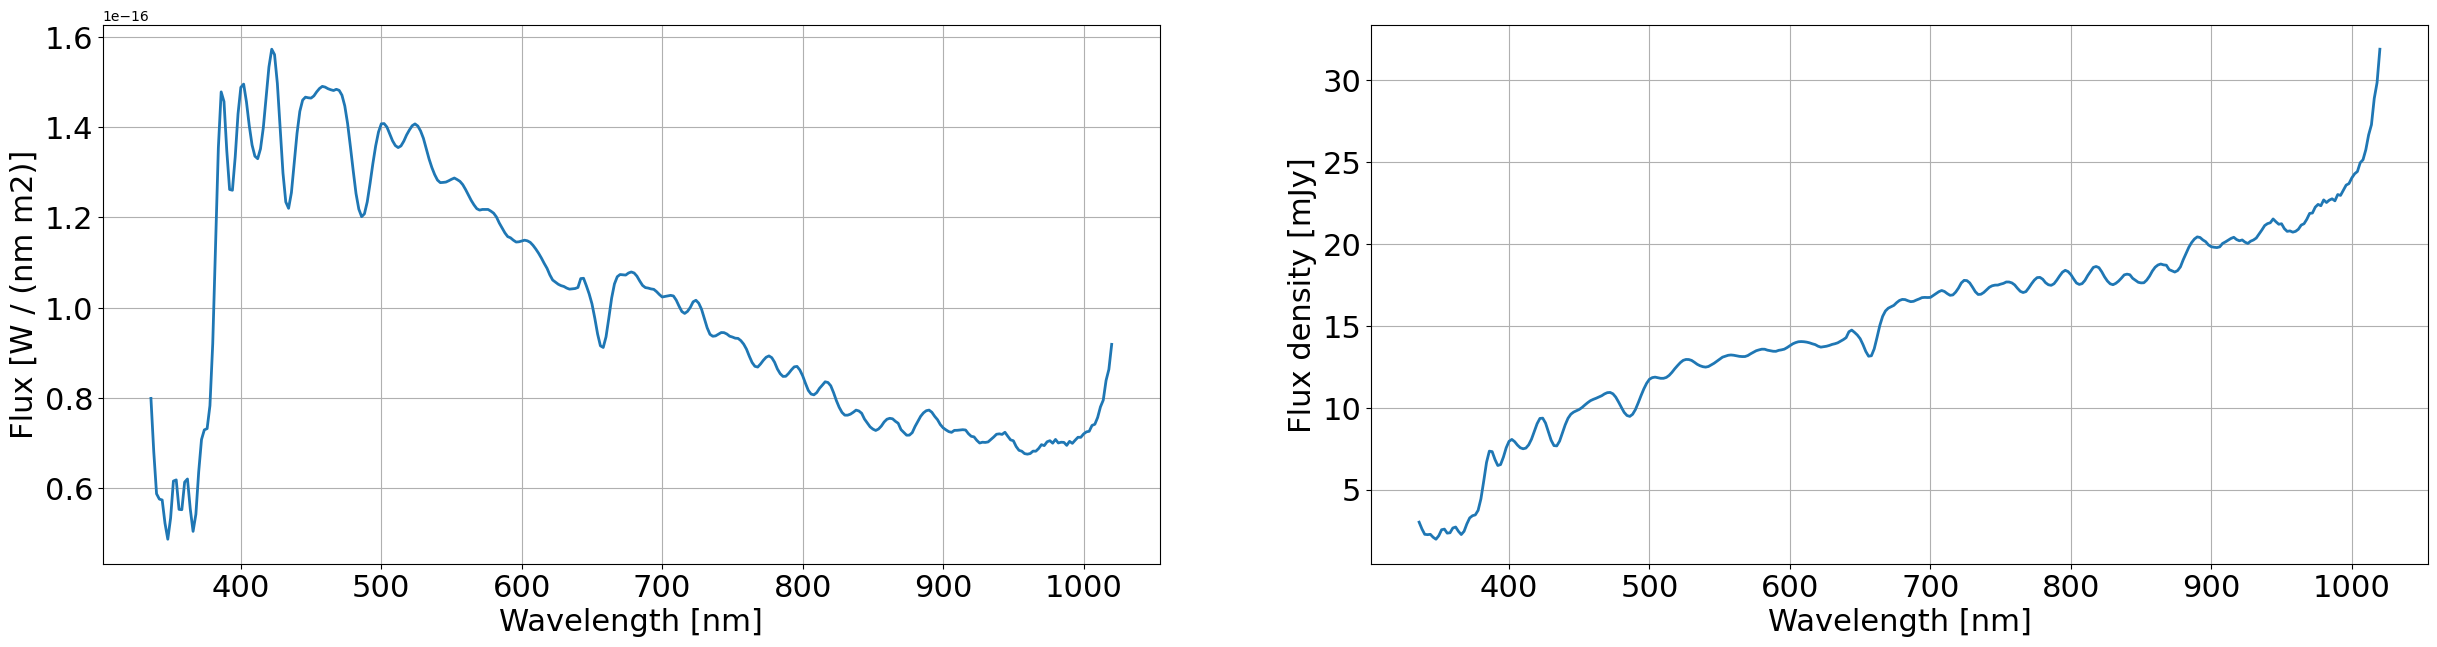

In [9]:
# Extract XP sampled spectra for a given source =======
outputs = [datalink[key][0] for key in datalink.keys()]
xp      = outputs[5].to_table()                        #  Plot the different spectra by changing '5' to e.g., 0, 1, ..., 9

# Add flux-density columns ============================
xp['flux_jy']         = xp['flux'].to(u.Jansky, equivalencies = u.spectral_density(xp['wavelength'].value * xp['wavelength'].unit))
xp['flux_mjy']        = xp['flux_jy'].to(u.millijansky)
xp['flux_mjy'].format = '7.4f'
display(xp)


# Plotter ==============================================
def make_canvas(xlabel = '', ylabel = '', fontsize = 12):
    plt.xlabel(xlabel,  fontsize = fontsize)
    plt.ylabel(ylabel, fontsize = fontsize)
    plt.xticks(fontsize = fontsize)
    plt.yticks(fontsize = fontsize)
    plt.grid()

fig       = plt.figure(figsize=[30,7])

plt.subplot(121)
plt.plot(xp['wavelength'], xp['flux'], linewidth = 2)
make_canvas(xlabel = f"Wavelength [{xp['wavelength'].unit}]", ylabel = f"Flux [{xp['flux'].unit}]", fontsize = 22)

plt.subplot(122)
plt.plot(xp['wavelength'], xp['flux_mjy'], linewidth = 2)
make_canvas(xlabel = f"Wavelength [{xp['wavelength'].unit}]", ylabel = f"Flux density [{xp['flux_mjy'].unit}]", fontsize = 22)

plt.show()